# Practice 6.
## Guillem Moreno Garcia
##  Objectives:
1. Understand the decision trees for the case of classification.
2. See the effects of changing the parameters of the tree.

## Aplication:
Data base: Datasets for "The Elements of Statistical Learning"
(https://web.stanford.edu/~hastie/ElemStatLearn/data.html)

 Database: coronary heart disease (CHD), https://web.stanford.edu/~hastie/ElemStatLearn/datasets/SAheart.data
- Predict **CHD** (1 or  0)


In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV



In [2]:
File = "SouthAfricanHeartDesease.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T

Filename with path: 
 C:\mlearn-lab\SixthPractice\Data\SouthAfricanHeartDesease.csv


,0,1,2,3,4
row.names,1,2,3,4,5
sbp,160,144,118,170,134
tobacco,12.0,0.01,0.08,7.5,13.6
ldl,5.73,4.41,3.48,6.41,3.5
adiposity,23.11,28.61,32.28,38.03,27.78
famhist,Present,Absent,Present,Present,Present
typea,49,55,52,51,60
obesity,25.3,28.87,29.14,31.99,25.99
alcohol,97.2,2.06,3.81,24.26,57.34
age,52,63,46,58,49


## Clean the database
###  Check there is no problem

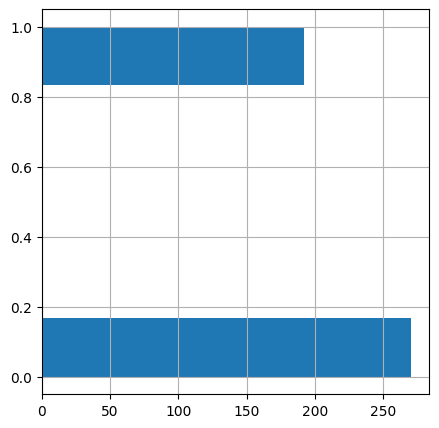

In [3]:
Coding_famhist ={'Present':1,'Absent':0}
Data['famhist'] = Data['famhist'].map(Coding_famhist)
ax =Data['famhist'].hist(figsize= (5,5),orientation="horizontal",bins = 6)

Data.drop(columns = ['row.names'],inplace = True)

### Let us see if the data is balanced

Note: predicted qualities are almost balanced 


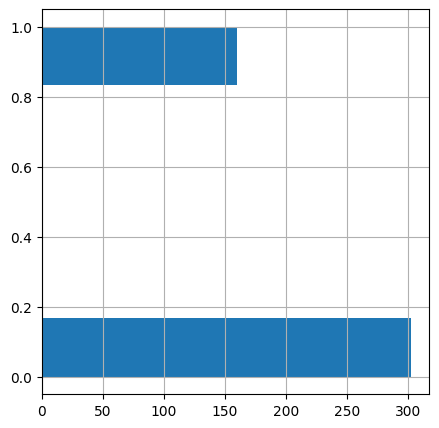

In [4]:
ax =Data['chd'].hist(figsize= (5,5),orientation="horizontal",bins = 6)
print('Note: predicted qualities are almost balanced ')

##  Let us see the histograms

###  Features that would give problems in a Linear Classifier, PCA, LDA, and others

1- **Different units** between features. Note that Decision Trees are robust to this feature, while in other ML techniques you should consider standarize (see practice 5)

2- Some features are not **Gaussian**

3- Some features have high **Standard Deviation**  (this is a problem for algorithms based on correlations)

4- Note that tobaco and alcohol have the median (percentile 50%) quite different from the mean. Also in these cases the standard deviation is bigger than the mean. In the future we will deal with features with these properties.

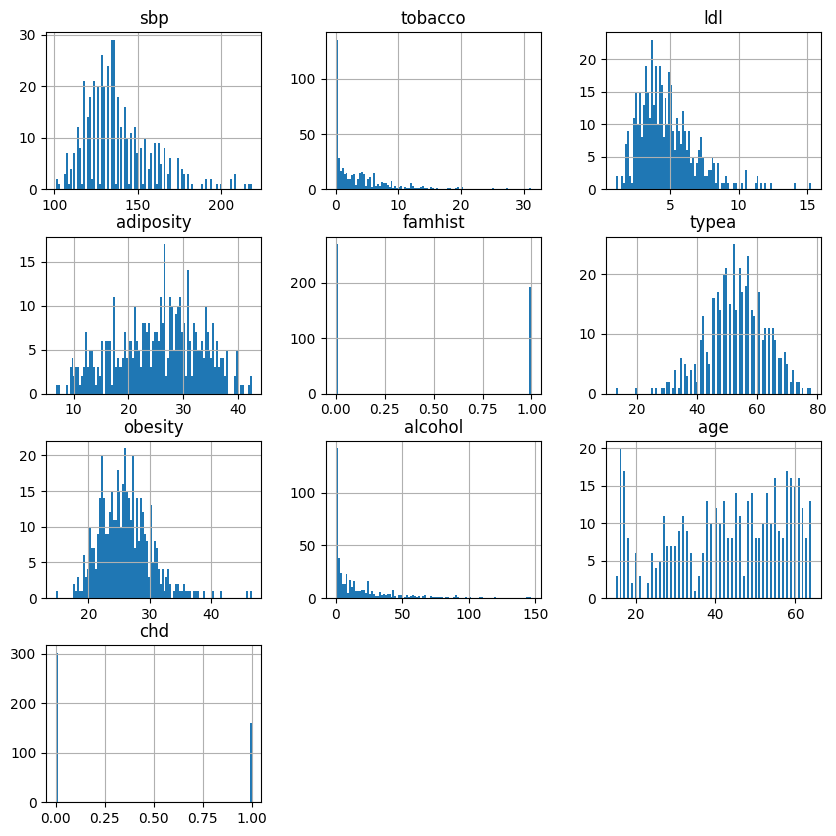

In [5]:
ax =Data.hist(figsize= (10,10),bins = 100)

### Excercise: <font color='red'> If we were working with a linear regression method, suggest a transformation for the variables tabaco and alcohol that might improve the working of the linear regression.</font>
**Spoiler:**  In decision trees it is not necessary. Explain why?

**Answer:** Tobacco and alcohol are strongly right-skewed variables, so for a linear method I would use `log1p(tobacco)` and `log1p(alcohol)`. The `log1p` transform works with zero values, compresses very large observations, and usually makes the relation with the target less dominated by outliers.

For decision trees this is usually not necessary because a tree only asks threshold questions such as `tobacco <= c`. Any increasing transformation keeps the order of the samples, so the tree can find an equivalent split with a transformed threshold. Scaling or logging may change the numerical threshold, but not the ranking information used by the split.

In [6]:
Data.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
sbp,462.0,138.33,20.50,101.00,124.00,134.00,148.00,218.00
tobacco,462.0,3.64,4.59,0.00,0.05,2.00,5.50,31.20
ldl,462.0,4.74,2.07,0.98,3.28,4.34,5.79,15.33
adiposity,462.0,25.41,7.78,6.74,19.77,26.12,31.23,42.49
famhist,462.0,0.42,0.49,0.00,0.00,0.00,1.00,1.00
typea,462.0,53.10,9.82,13.00,47.00,53.00,60.00,78.00
obesity,462.0,26.04,4.21,14.70,22.98,25.80,28.50,46.58
alcohol,462.0,17.04,24.48,0.00,0.51,7.51,23.89,147.19
age,462.0,42.82,14.61,15.00,31.00,45.00,55.00,64.00
chd,462.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00


## Let us look into the scatter plot matrix to see if there is a regularity in the data

In [7]:
if False:
    ax = pd.plotting.scatter_matrix(Data,c =Data['chd'], figsize = (10,10))

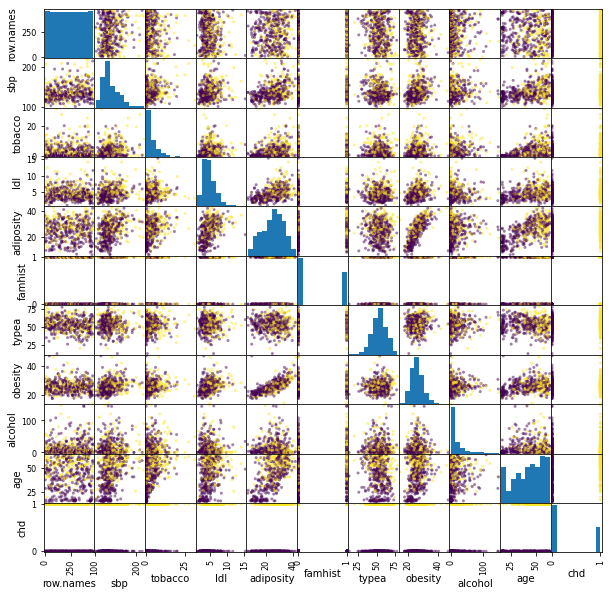

### Excercise: <font color='red'> Note that adiposity and obesity input variables are correlated .</font>
1. Explain *briefly*, why this is bad in the case of linear regression (or similar procedures).
2. Explain *briefly*, why in decision trees this is not so important.

**Answer:**

1. In linear regression or logistic regression, correlated input variables create multicollinearity. The model has difficulty deciding which variable deserves the coefficient, so coefficients can become unstable, sensitive to the train/test split, and harder to interpret.
2. In a decision tree this is less serious for prediction because the tree can choose one of the correlated variables for a split and ignore the other, or use the second one later if it still improves purity. The main caution is interpretability: importance can be shared or swapped between correlated variables, so the hierarchy should not be read as a perfect causal ranking.

## Let us train a classifier

##  First we partition database into train and test
### Note the helper function

In [8]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)

In [9]:
y = TrainDB['chd']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'chd']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age']
__________________________________________________


### We create the decision tree object and fit the model to the Training database.

In [10]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, y)

##  We print the decision rules that explain how the **diagnosis** is **explained** by the data.

1. ###  Note the hierarchy of variables. 
1. ###  Note the depth of the tree.

<font color='blue'> **Concept:** Works like a look up table. </font>

In [11]:
r = export_text(clf, feature_names=InputFeatures)
print(r)

|--- age <= 50.50
|   |--- age <= 31.50
|   |   |--- obesity <= 19.53
|   |   |   |--- obesity <= 18.17
|   |   |   |   |--- class: 0
|   |   |   |--- obesity >  18.17
|   |   |   |   |--- class: 1
|   |   |--- obesity >  19.53
|   |   |   |--- tobacco <= 6.45
|   |   |   |   |--- sbp <= 109.00
|   |   |   |   |   |--- alcohol <= 11.46
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- alcohol >  11.46
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- sbp >  109.00
|   |   |   |   |   |--- typea <= 41.50
|   |   |   |   |   |   |--- typea <= 40.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- typea >  40.00
|   |   |   |   |   |   |   |--- obesity <= 27.84
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- obesity >  27.84
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- typea >  41.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- tobacco >  6.45
|   |   |   |   |--- class: 1
|   |-

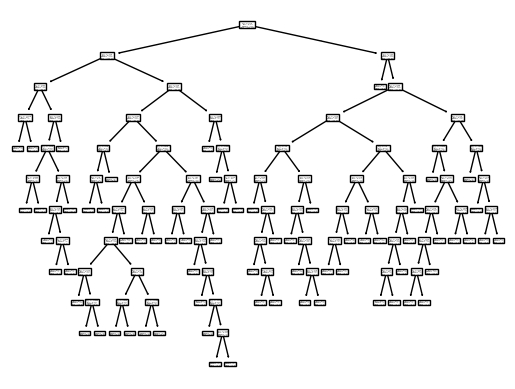

In [12]:
tree.plot_tree(clf)
plt.show()

### Excercise: <font color='red'> Provide a short common sense explanation of why a tree that works like a **look up table** is a bad solution .</font>

**Answer:** A tree that works like a look-up table is usually too deep: it memorizes very specific combinations of the training samples instead of learning general patterns. That can produce excellent training accuracy, but the rules are fragile and do not transfer well to new patients. In practice this is overfitting: the model starts learning noise, outliers, and accidents of the split.

### Next we look at the details of the higher levels.

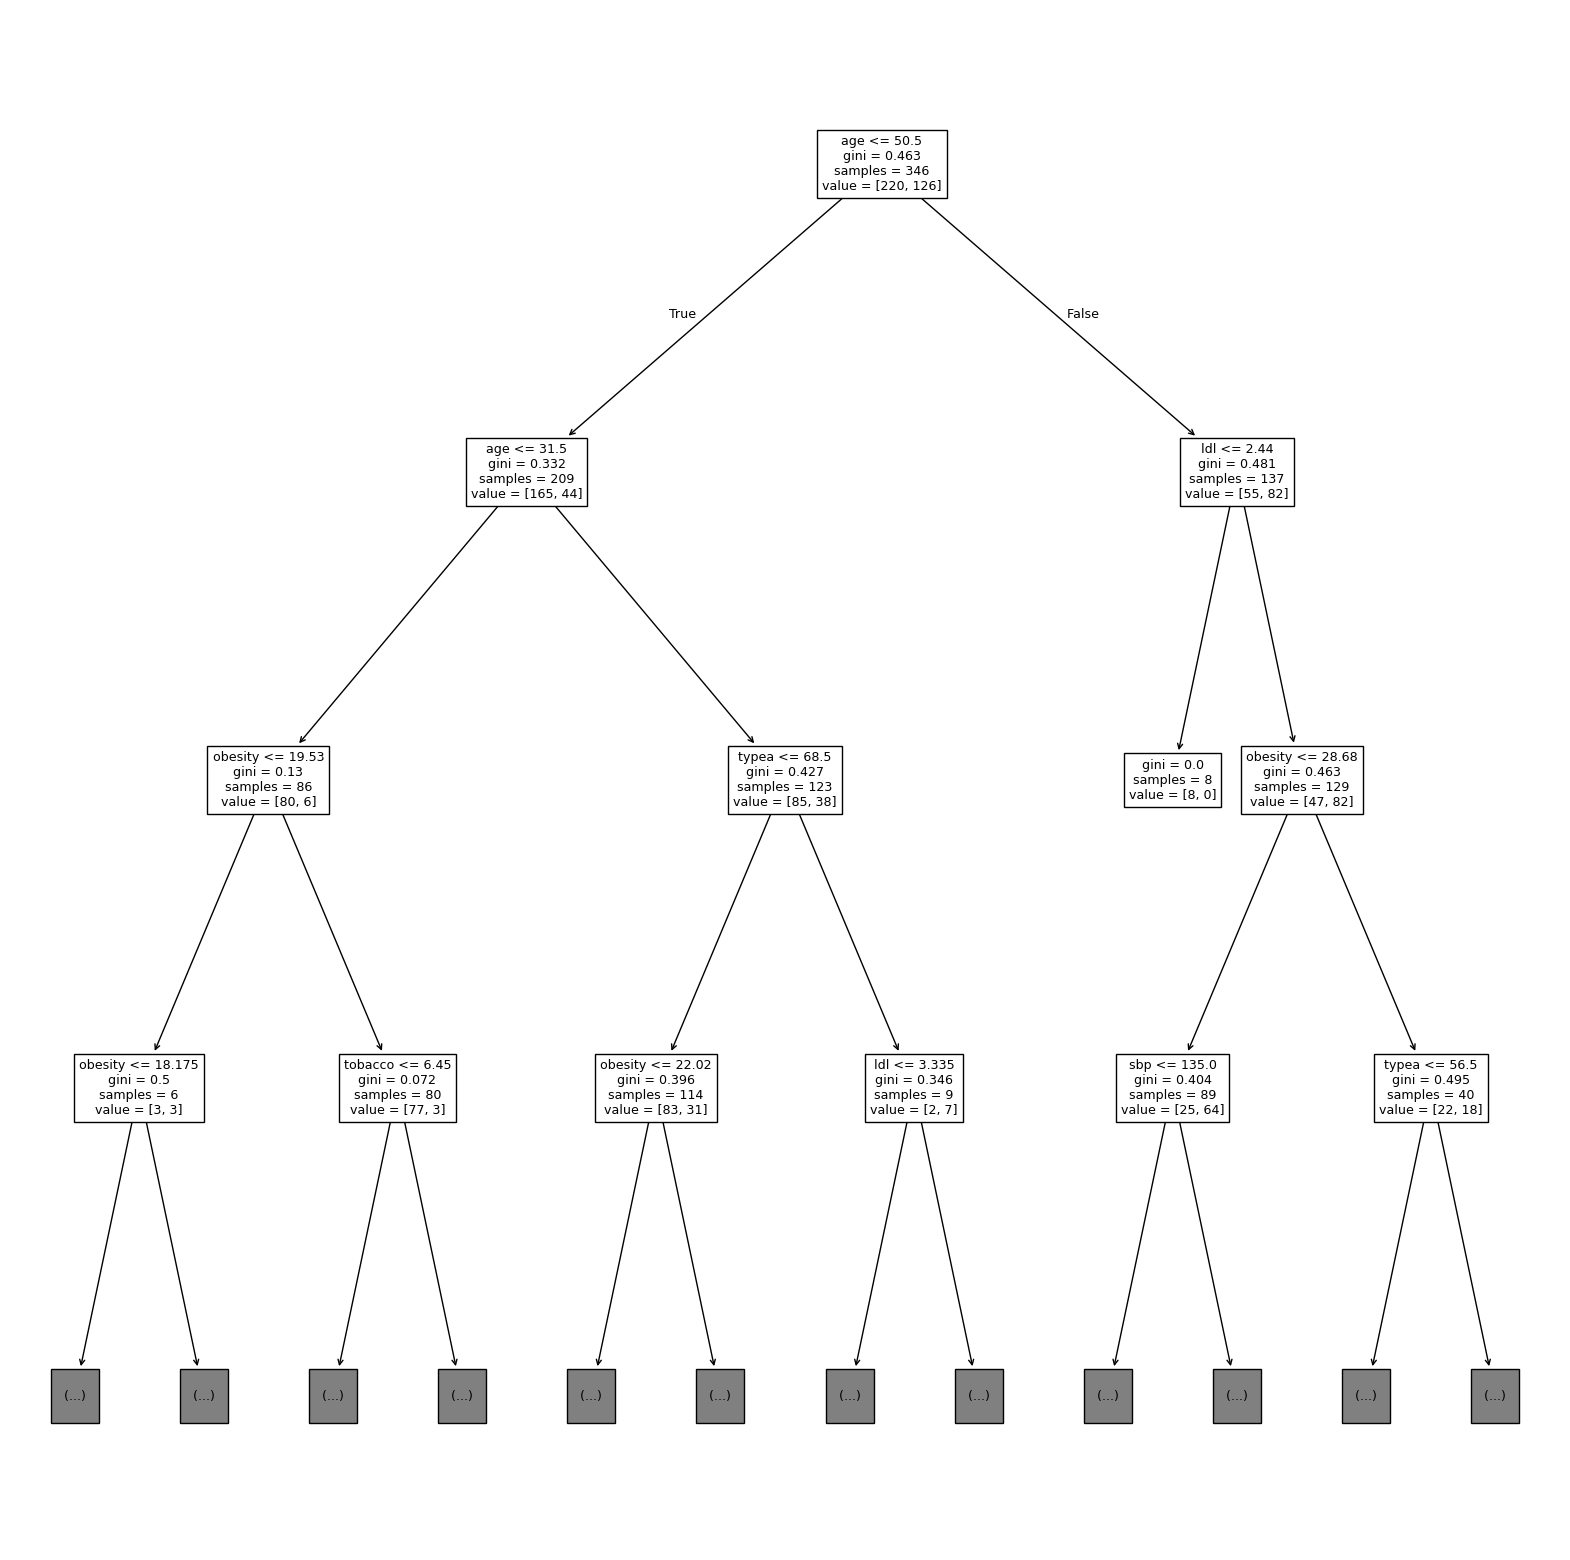

In [13]:
plt.figure(figsize=(20,20))
ax = tree.plot_tree(clf,max_depth = 3,feature_names = InputFeatures,impurity = True)
plt.show()

### Homework: <font color='red'>  Try to see if there is a similarity between the information given by the scatter plot and the hierarchy of variables. Note that a set of questions along one branch can be seen as a kind of correlation</font>

<font color='red'>  See the Gini Coefficients, they are are near 1/2 in the higher nodes but disminishes in the lower ones. Why?  Note the variable **Value**, is giving the number of elements of each class</font>

**Answer:** The scatter plot matrix suggests that variables such as age, tobacco, ldl, adiposity, and famhist contain visible information about CHD, while adiposity and obesity also share redundant information. This is similar to the tree hierarchy: the highest splits tend to use variables that separate the two classes most clearly, and a full branch can be read as a sequence of conditions that describes an interaction between variables.

The Gini coefficient is close to 0.5 in the upper nodes because those nodes still contain a mixed population of `chd = 0` and `chd = 1`; for a binary problem, a balanced and impure node has Gini near 0.5. After useful splits, the `value` counts become more dominated by one class, so the lower nodes become purer and the Gini coefficient decreases toward 0.

## Let us control the training of the tree

1. min_samples_split: We want to control the number in order to have significative statistics.

2. max_depth: depth we allow for the tree. Will stop growth.

3. min_samples_leaf: We want to have enoughs examples per decision.

4. class_weight:  Allows to control balance between *True Positives* and *False Negatives*.

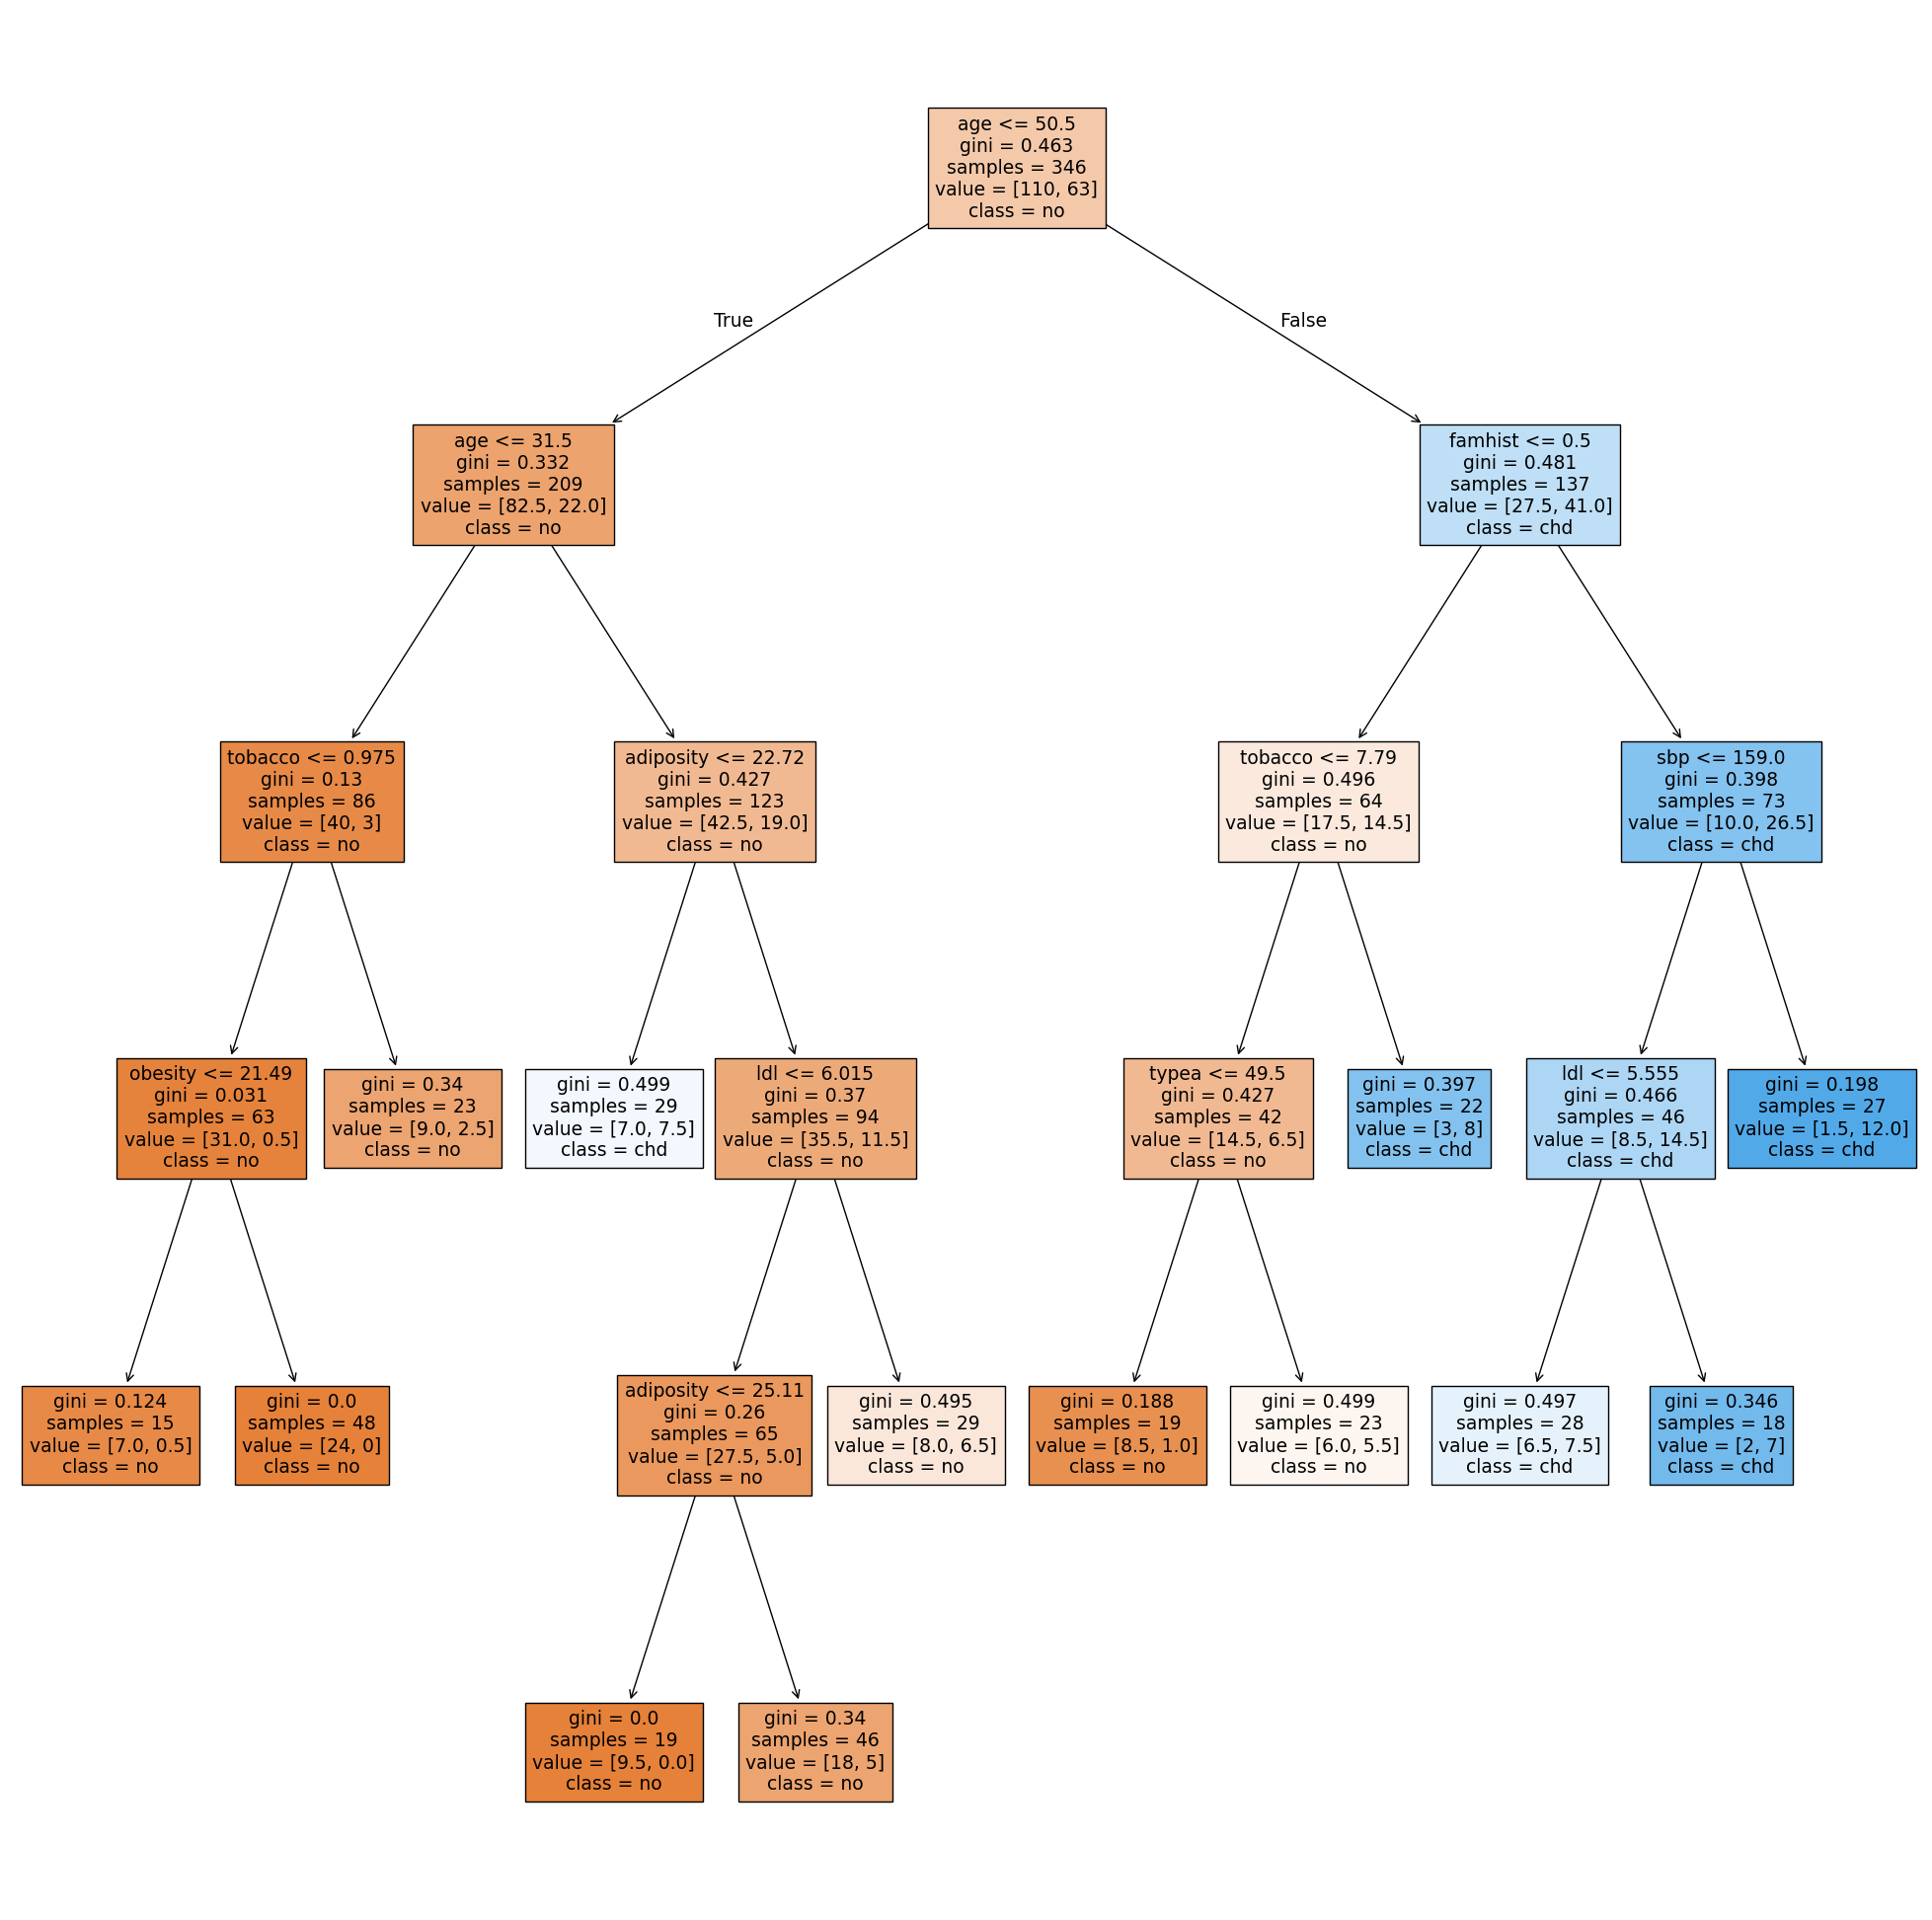

In [14]:
clf = tree.DecisionTreeClassifier(min_samples_split = 10,max_depth =5,min_samples_leaf =15,class_weight = {0:0.5,1:0.5})
clf = clf.fit(X, y)
plt.figure(figsize=(25,25))
ax = tree.plot_tree(clf,feature_names = InputFeatures,impurity = True,class_names =['no','chd'],filled = True)
plt.show()

## Behaviour on test database
### Performance index: Accuracy score

**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$

**Note:** There are more performance indices. We will see them further in the course.

##  Performance on train

Accuracy (train)  76.3% 
[[180  40]
 [ 42  84]]


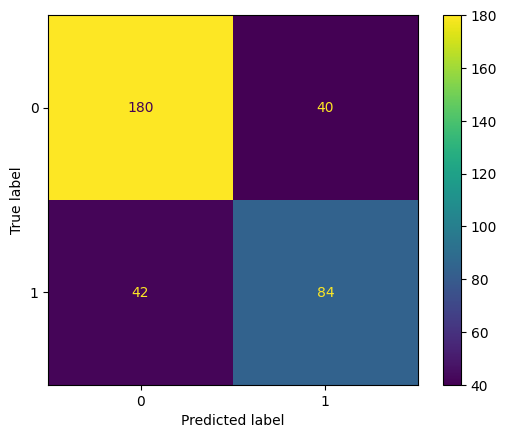

In [15]:
y_hat = clf.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_estimator(clf, X, y)  
plt.show()

## Performance on test

Accuracy (test)  63.8% 
Predicted Label   0   1
True Label             
0                62  20
1                22  12


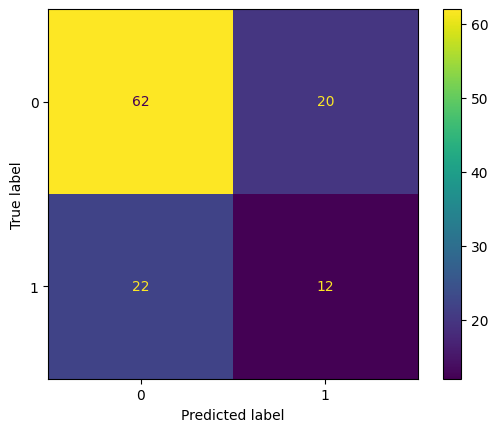

In [16]:
y_tst = TestDB['chd']
X_tst = TestDB[InputFeatures]
y_hat_tst = clf.predict(X_tst)
accuracy = accuracy_score(y_tst, y_hat_tst)
print("Accuracy (test)  %0.1f%% " % ( accuracy * 100))

# Pretty print the confusion matrix with labels
labels = sorted(list(set(y_tst)))

cm = confusion_matrix(y_tst, y_hat_tst)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
df_cm.index.name = 'True Label'
df_cm.columns.name = 'Predicted Label'

print(df_cm)

ConfusionMatrixDisplay.from_estimator(clf, X_tst, y_tst)  
plt.show()

**Interpretation of the test result:** The test accuracy is 63.8%, so this decision tree is useful as a learning exercise and as an interpretable baseline, but it is not strong enough to be considered a real medical classifier.

The confusion matrix also shows an important clinical weakness: the model detects only 12 of the 34 CHD-positive cases, so the sensitivity is $12/(12+22)=35.3\%$. In other words, it misses many CHD cases. For a health problem, these false negatives are especially important because they correspond to patients with CHD predicted as not having CHD.

## Cross-validation to find the optimal parameters


1. min_samples_split: We want to control the number in order to have significative statistics.

2. max_depth: depth we allow for the tree. Will stop growth.

3. min_samples_leaf: We want to have enoughs examples per decision.

4. class_weight:  Allows to control balance between *True Positives* and *False Negatives*.

In [17]:
# 1. Prepare the training data as requested
X_train = TrainDB[InputFeatures]
y_train = TrainDB['chd']

# 2. Define the parameter grid for the Decision Tree
param_grid = {
    'min_samples_split': [2, 10, 20, 50],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced', {0: 1, 1: 2}]
}

# 3. Initialize and run GridSearchCV
dt_classifier = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dt_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# 4. Evaluate the best estimator on train and test
best_model = grid_search.best_estimator_
y_hat_train_cv = best_model.predict(X_train)
y_hat_tst = best_model.predict(X_tst)
train_accuracy_cv = accuracy_score(y_train, y_hat_train_cv)
test_accuracy_cv = accuracy_score(y_tst, y_hat_tst)

print('Best Parameters:', grid_search.best_params_)
print('Accuracy (cross validation): %0.1f%%' % (grid_search.best_score_ * 100))
print('Accuracy (train, best CV model): %0.1f%%' % (train_accuracy_cv * 100))
print('Accuracy (test, best CV model): %0.1f%%' % (test_accuracy_cv * 100))

labels = sorted(list(set(y_tst)))
cm = confusion_matrix(y_tst, y_hat_tst, labels=labels)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
df_cm.index.name = 'True Label'
df_cm.columns.name = 'Predicted Label'
print()
print('Confusion Matrix:')
print(df_cm)

Best Parameters: {'class_weight': None, 'max_depth': None, 'min_samples_leaf': 20, 'min_samples_split': 50}
Accuracy (cross validation): 69.7%
Accuracy (train, best CV model): 76.3%
Accuracy (test, best CV model): 63.8%

Confusion Matrix:
Predicted Label   0   1
True Label             
0                62  20
1                22  12


### Homework: <font color='red'>  Compare briefly with the results above in train and test.</font>

**Answer:** In the current executed notebook, the best parameters selected by `GridSearchCV` are `class_weight=None`, `max_depth=None`, `min_samples_leaf=20`, and `min_samples_split=50`. Here, `None` means that cross-validation did not choose class reweighting and did not choose an explicit maximum depth. The tree is still controlled because `min_samples_leaf=20` and `min_samples_split=50` prevent very small leaves and very small splits.

The final model has 69.7% mean cross-validation accuracy, 76.3% train accuracy, and 63.8% test accuracy. The 69.7% value is the average validation score used to choose the hyperparameters. The 63.8% value is the held-out test accuracy, so this is the number I would report as the final performance on unseen data.

The test result is lower than the train result, which suggests that the model still has some generalization difficulty. The confusion matrix is also important: the sensitivity is low, so accuracy alone gives an incomplete view of the classifier.

#### <font color='red'> For a job interview </font>
Why the number 42 ? (random_state=42)

**Ask google**: what is the number 42?

**Answer:** In machine learning code, `random_state=42` simply fixes the pseudo-random generator so that train/test splits, tie-breaking, or randomized algorithms can be reproduced. The number 42 has no special mathematical advantage here. It is a popular joke/reference from *The Hitchhiker's Guide to the Galaxy*, where 42 is given as the answer to the ultimate question of life, the universe, and everything.

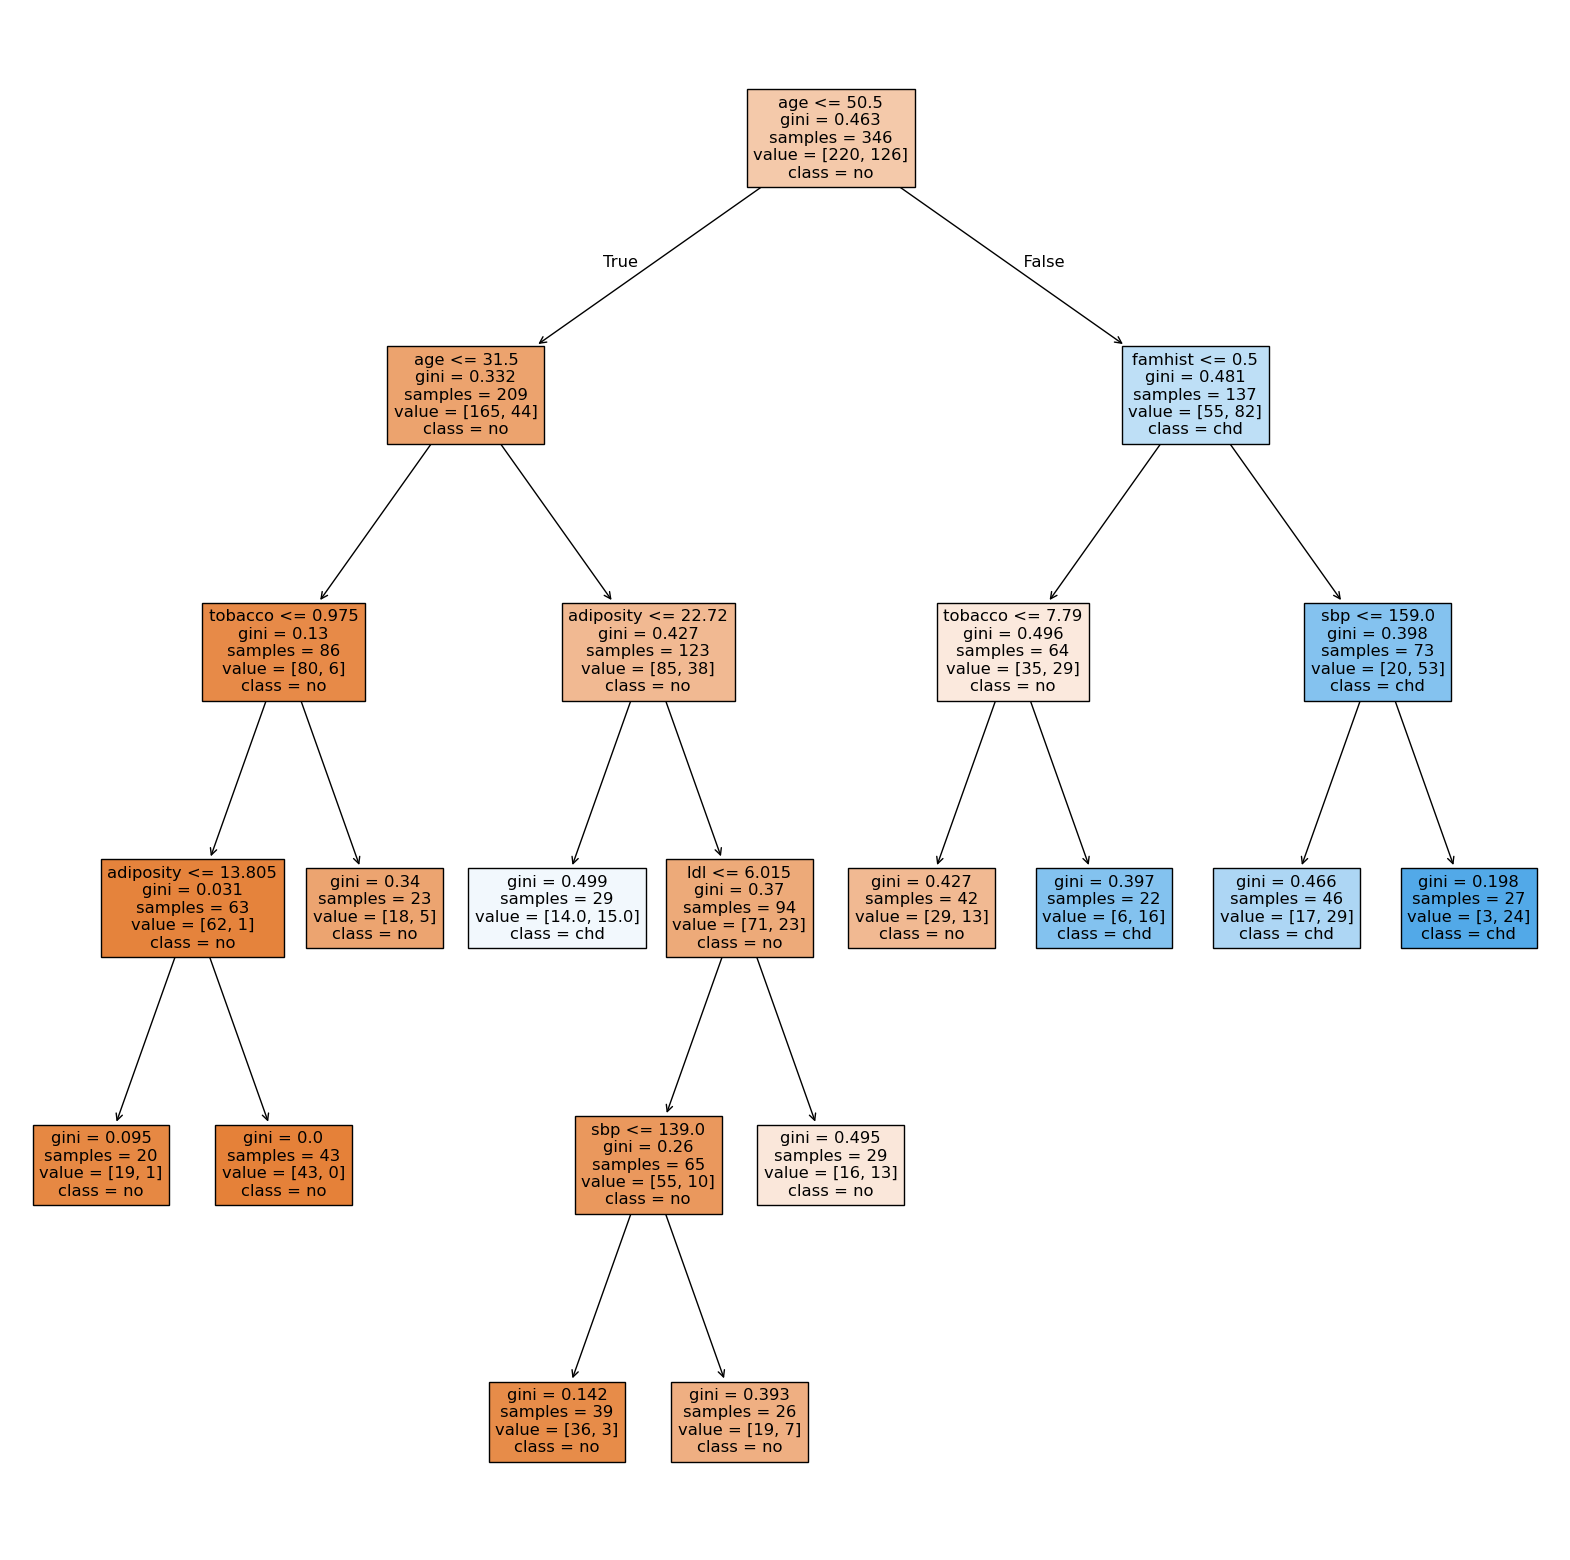

In [18]:
plt.figure(figsize=(20,20))
ax = tree.plot_tree(best_model,feature_names = InputFeatures,impurity = True,class_names =['no','chd'],filled = True)
plt.show()

### Homework: <font color='red'>   Compute the performance after standarizing the data, so that it has mean zero and standard deviation equal to one. </font>
I.e. $z = {(x - mean) \over  std}$  (see practice 5 for an example)

**Answer:** As we can see below, after standardizing the variables the decision tree keeps the same performance as the original scale: about 76.3% accuracy on train and 63.8% on test.

### Homework: <font color='red'>    Explain the result.</font>

**Answer:** This result is expected because standardization changes the units but preserves the order of the samples. A decision tree mainly uses threshold questions, so it can recreate the same split with a different numerical threshold. The standardization is also done correctly: the `StandardScaler` is fitted only on the training data and then applied to the test data, which avoids test-data leakage.

### Homework: <font color='red'>    Compute the new tree setting alcohol and tobaco in logarithmic scale. This should improve quite a lot the performance in the case of linear classifiers, etc. What happens with the decision tree? </font>

**Answer:** As we can see below, using `log1p` for tobacco and alcohol also gives practically the same result: about 76.3% accuracy on train and 63.8% on test.

### Homework: <font color='red'>    Explain the result.</font>

**Answer:** Logarithmic transformations are useful for linear classifiers because they reduce skewness and the influence of extreme values. For a decision tree, the transformation is less important because the logarithm is monotonic: it changes the scale, but it mostly keeps the same ordering of observations. Therefore the tree usually chooses equivalent splits and the performance barely changes. This log transformation does not learn parameters from the test set, so it does not introduce leakage.

The following cell computes both experiments using the same train/test partition and the same controlled tree parameters used above.

              Variant  Train accuracy (%)  Test accuracy (%)
       Original scale                76.3               63.8
         Standardized                76.3               63.8
log1p tobacco/alcohol                76.3               63.8


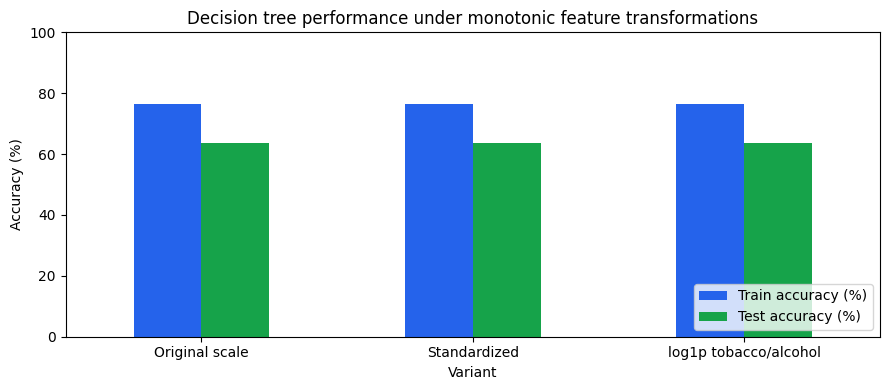

In [19]:
from sklearn.preprocessing import StandardScaler

controlled_tree_params = {
    'min_samples_split': 10,
    'max_depth': 5,
    'min_samples_leaf': 15,
    'class_weight': {0: 0.5, 1: 0.5},
    'random_state': 42,
}

def evaluate_tree_variant(X_train_variant, X_test_variant, label):
    model = DecisionTreeClassifier(**controlled_tree_params)
    model.fit(X_train_variant, y)
    y_hat_train = model.predict(X_train_variant)
    y_hat_test = model.predict(X_test_variant)
    return {
        'variant': label,
        'train_accuracy': accuracy_score(y, y_hat_train),
        'test_accuracy': accuracy_score(y_tst, y_hat_test),
        'model': model,
    }

# Baseline with the original feature scales.
variant_results = [evaluate_tree_variant(X, X_tst, 'Original scale')]

# Standardized data: fit the scaler only on the training data.
scaler = StandardScaler()
X_train_std = pd.DataFrame(scaler.fit_transform(X), columns=InputFeatures, index=X.index)
X_test_std = pd.DataFrame(scaler.transform(X_tst), columns=InputFeatures, index=X_tst.index)
variant_results.append(evaluate_tree_variant(X_train_std, X_test_std, 'Standardized'))

# Log-transform only the skewed alcohol and tobacco variables.
X_train_log = X.copy()
X_test_log = X_tst.copy()
for col in ['tobacco', 'alcohol']:
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])
variant_results.append(evaluate_tree_variant(X_train_log, X_test_log, 'log1p tobacco/alcohol'))

comparison = pd.DataFrame([
    {
        'Variant': result['variant'],
        'Train accuracy (%)': 100 * result['train_accuracy'],
        'Test accuracy (%)': 100 * result['test_accuracy'],
    }
    for result in variant_results
]).round(1)

print(comparison.to_string(index=False))

ax = comparison.set_index('Variant')[['Train accuracy (%)', 'Test accuracy (%)']].plot(
    kind='bar',
    figsize=(9, 4),
    ylim=(0, 100),
    rot=0,
    color=['#2563eb', '#16a34a']
)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Decision tree performance under monotonic feature transformations')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.

### Executive report

This practice studied the South African Heart Disease dataset using decision trees for binary classification of CHD. The workflow cleaned the categorical `famhist` variable, checked class balance, explored the distributions, trained a first unrestricted tree, then controlled the model complexity with parameters such as `max_depth`, `min_samples_split`, and `min_samples_leaf`. The controlled tree is easier to interpret and less likely to behave like a look-up table.

The final held-out test accuracy is 63.8%, while the mean cross-validation accuracy used for model selection is 69.7%. Therefore, the model is useful for understanding decision trees and obtaining an interpretable baseline, but it is not strong enough for real medical decision-making.

The main difficulty is that the dataset is relatively small and contains correlated and skewed variables. The test confusion matrix also shows a low sensitivity of 35.3%, because the model identifies only 12 of the 34 CHD-positive patients. This means false negatives are a serious limitation: many patients with CHD are predicted as not having CHD.

A practical solution would be to keep the interpretable tree as a baseline, tune it with cross-validation, and compare it with more robust alternatives such as pruned trees, random forests, gradient boosting, and logistic regression with feature transformations. For a health-related application, accuracy alone is not enough: sensitivity, specificity, false negatives, calibration, and clinical interpretability should also be reported before using the model for real decisions.

 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

**Prompt used for generation:** Create a clean academic infographic titled "Decision Trees for CHD Prediction". Use a white background with blue, green, and red accents. Include five compact sections: 1) Dataset: South African Heart Disease data, binary target CHD, features such as age, tobacco, ldl, adiposity, famhist, obesity, and alcohol. 2) Workflow: clean categorical variables, inspect distributions, split train/test, train a decision tree, and tune hyperparameters with cross-validation. 3) Results: controlled decision tree train accuracy 76.3%, test accuracy 63.8%; cross-validation accuracy 69.7%; best CV tree test accuracy 63.8%; confusion matrix on test has TN=62, FP=20, FN=22, TP=12. 4) Key insight: the test accuracy is lower than the train accuracy, so the tree still has generalization difficulty; standardization and log1p(tobacco/alcohol) produce the same 76.3% train and 63.8% test accuracy because decision-tree splits depend mainly on feature order. 5) Recommendation: report confusion matrix, sensitivity/specificity, compare with pruned trees or ensemble methods, and treat accuracy alone as insufficient for health-related decisions. Use simple icons, clear arrows, and short readable text blocks suitable for a machine learning class report.

**Infographic generated with imagegen:**

![Decision Trees for CHD Prediction](InfographicPractice6.png)


## Description of variables: coronary heart disease (CHD)

A retrospective sample of males in a heart-disease high-risk region
of the Western Cape, South Africa. There are roughly two controls per
case of CHD. Many of the CHD positive men have undergone blood
pressure reduction treatment and other programs to reduce their risk
factors after their CHD event. In some cases the measurements were
made after these treatments. These data are taken from a larger
dataset, described in  Rousseauw et al, 1983, South African Medical
Journal. 
### Input variables:

* sbp systolic blood pressure
* tobacco cumulative tobacco (kg)
* ldl low densiity lipoprotein cholesterol
* adiposity
* famhist family history of heart disease (Present, Absent)
* typea type-A behavior
* obesity
* alcohol current alcohol consumption
* age age at onset
* chd response, coronary heart disease